# Simulating DCR-Induced Ellipticity from Blackbody SEDs

**Differential Chromatic Refraction (DCR)** causes the atmosphere to deflect light by an angle that depends on wavelength — shorter (bluer) wavelengths are refracted more. For a broadband source, this stretches the PSF along the altitude direction, producing a measurable **ellipticity signature**.

The key dependencies are:
- **Source SED** — bluer (hotter) sources show stronger DCR because they have more flux at short wavelengths where refraction is greatest
- **Zenith angle ζ** — DCR shifts scale as tan(ζ), so the PSF second-moment contribution scales as tan²(ζ)
- **Observing band** — bluer/broader bands are more affected

This notebook simulates blackbody SEDs of varying temperatures, computes their DCR-induced PSF ellipticity across the LSST `ugrizy` bands and a range of zenith angles, and shows how the signal varies with source g−r color.

In [1]:
# Import packages and define functions

import numpy as np
import matplotlib.pyplot as plt
import galsim

from astropy.io.votable import parse
from scipy.interpolate import interp1d

import astropy.units as u
from astropy.time import Time
from astropy.coordinates import EarthLocation, Angle, AltAz, SkyCoord

import gala.coordinates as gc
import astropy.coordinates as coord

from scipy.optimize import curve_fit

from scipy import integrate

from utils import apply_filter, apply_DCR, BB, mean_and_std


colors = {'u' : 'purple', 'g':'blue', 'r': 'green', 'i': 'orange', 'z' : 'magenta', 'y' : 'red'}

## 1. Source and Reference SEDs

We model sources as **blackbodies** parameterized by temperature. DCR shifts are always measured *relative to a reference SED* (here a 4500 K blackbody, approximating a typical survey star used for astrometric calibration). This means we compute **differential** DCR — the shift of a given source with respect to the reference — because absolute calibration removes the mean refraction.

Each SED is convolved with the LSST filter throughputs to get the per-band flux distributions that drive the DCR calculation.

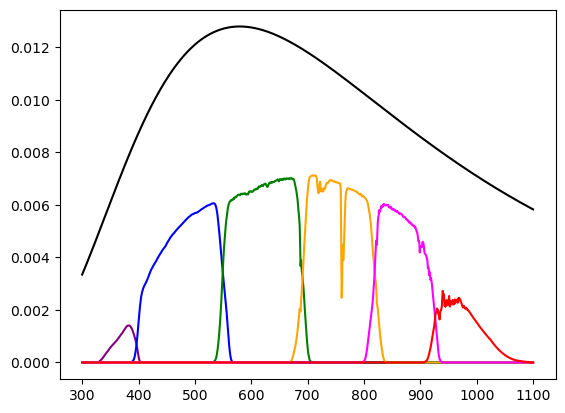

In [2]:
source_temperature = 5000     # K — source SED (will be swept over later)
reference_temperature = 4500  # K — reference SED (typical survey star for astrometric calibration)

wave = np.linspace(300, 1100, 1000)  # nm — wavelength grid spanning all LSST bands
BB_sed = BB(wave, source_temperature, scale=1e-8)
ref_sed = BB(wave, reference_temperature, scale=1e-8)

plt.plot(wave, BB_sed, 'k-')

BB_filtered = {}
ref_filtered = {}
for band in 'ugrizy':
    # Apply LSST filter throughput — selects the in-band flux that drives refraction
    filtered_sed = apply_filter(wave, BB_sed, band)
    BB_filtered[band] = filtered_sed

    filtered_ref = apply_filter(wave, ref_sed, band)
    ref_filtered[band] = filtered_ref

    plt.plot(wave, BB_filtered[band], color=colors[band], label=band)


## 2. DCR First and Second Moments

For a source with SED $S(\lambda)$ observed through filter $T(\lambda)$, the atmospheric refraction angle at each wavelength is $R(\lambda)$. The **flux-weighted moments** of $R$ determine how DCR affects the source in an image:

- **DCR1** (first moment) — the flux-weighted mean refraction of the source minus that of the reference. This is the differential astrometric centroid shift along the altitude axis.
- **DCR2** (second moment) — the flux-weighted variance of refraction: $\langle R^2 \rangle - \langle R \rangle^2$. This extra variance is added to the PSF second moment along altitude, broadening and shearing the PSF.

Both moments scale as $\tan^2(\zeta)$ with zenith angle, so we use $\tan^2(\zeta)$ as the x-axis when fitting or comparing across conditions.

Text(0, 0.5, 'Second moment shift (arcsec$^2$)')

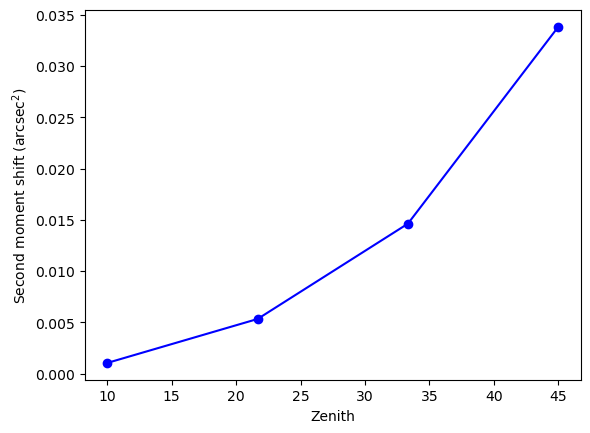

In [3]:
zeniths = np.linspace(10, 45, 4)  # zenith angles in degrees to sweep

DCR1 = {}  # differential mean refraction per band (arcsec)
DCR2 = {}  # variance of refraction per band (arcsec²) — added to PSF second moment

for band in 'ugrizy':
    DCR1[band] = np.array([])
    DCR2[band] = np.array([])

# Atmospheric conditions representative of the LSST site (Cerro Pachón)
pressure = 69.328      # kPa
temperature = 293.15   # K (~20°C)
H2O_pressure = 1.067   # kPa

for zenith in zeniths:
    # apply_DCR returns per-wavelength refraction angles and the flux-weighted SED at each angle
    refraction_angles, filtered_refracted_data = apply_DCR(wave, BB_filtered, zenith, pressure, temperature, H2O_pressure)
    R_mean, R_stdev = mean_and_std(refraction_angles, filtered_refracted_data)  # arcsec

    # Repeat for the reference SED; DCR1 is the differential shift source − reference
    refraction_angles, filtered_refracted_data_ref = apply_DCR(wave, ref_filtered, zenith, pressure, temperature, H2O_pressure)
    R_mean_ref, R_stdev_ref = mean_and_std(refraction_angles, filtered_refracted_data_ref)  # arcsec

    for band in 'ugrizy':
        DCR1[band] = np.append(DCR1[band], R_mean[band] - R_mean_ref[band])
        DCR2[band] = np.append(DCR2[band], (R_stdev[band])**2)  # variance = stdev²

plt.plot(zeniths, DCR2['g'], 'b-o', label='g')
plt.xlabel('Zenith')
plt.ylabel('Second moment shift (arcsec$^2$)')


## 3. Converting PSF Second Moments to Ellipticity

A PSF described by second moments $(I_{xx}, I_{yy}, I_{xy})$ has **distortion-convention ellipticity** components:

$$e_1 = \frac{I_{xx} - I_{yy}}{I_{xx} + I_{yy} + 2\sqrt{I_{xx} I_{yy} - I_{xy}^2}}, \qquad e_2 = \frac{2 I_{xy}}{I_{xx} + I_{yy} + 2\sqrt{I_{xx} I_{yy} - I_{xy}^2}}$$

We start from a **circular PSF** with $I_{xx} = I_{yy}$ (corresponding to a 6-pixel FWHM at 0.2″/pixel) and $I_{xy} = 0$. DCR stretches the PSF along the altitude axis (identified here with $y$), so DCR2 is added only to $I_{yy}$. This produces:
- $e_1 < 0$ — source is elongated along $y$ (altitude direction)
- $e_2 = 0$ — no 45° cross-term because DCR is purely axis-aligned

0.24000000000000005
1.1512601791080939


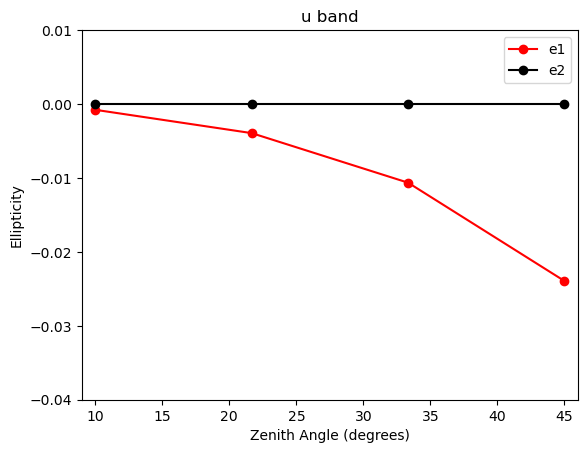

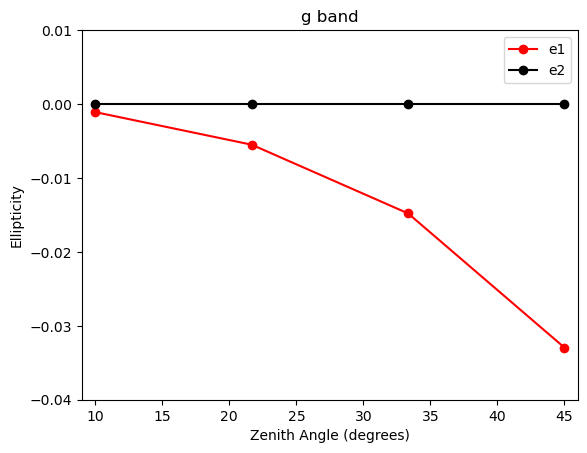

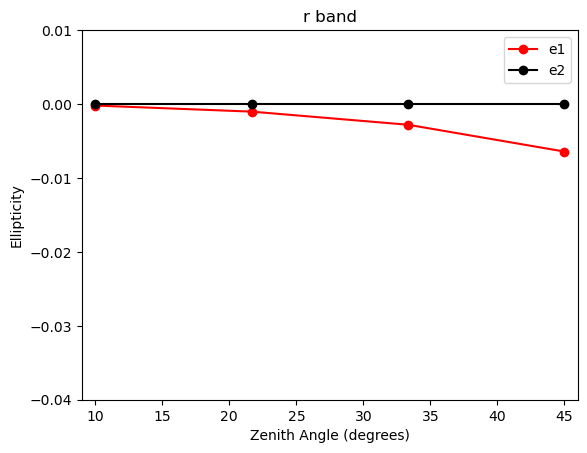

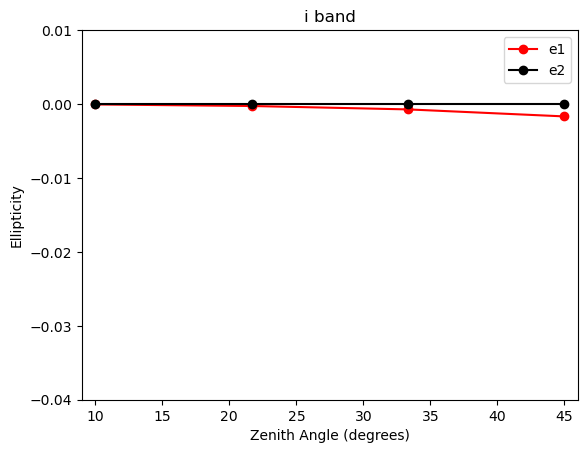

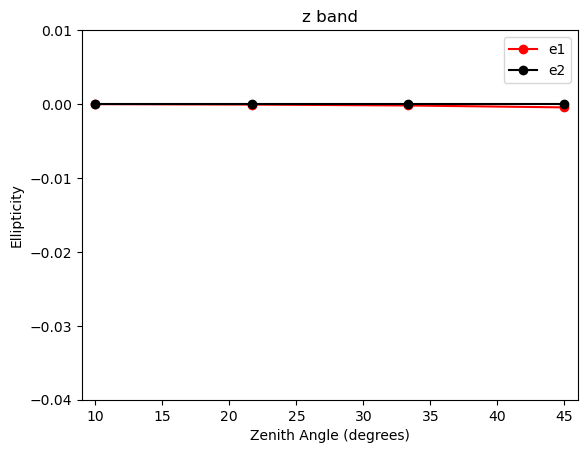

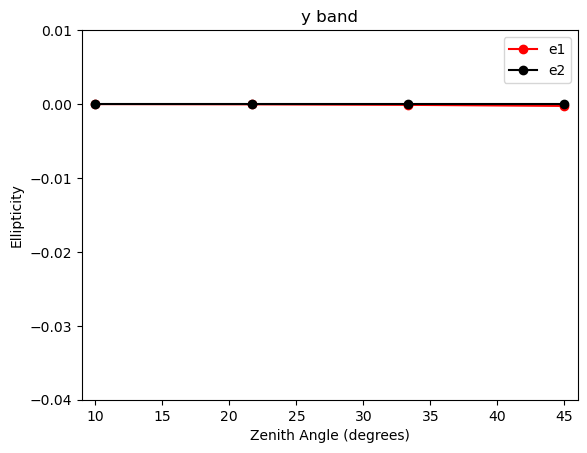

In [4]:
# Baseline PSF second moments — circular PSF, 6 pixels × (0.2"/pixel)² plate scale
shape_xx = 6 * (0.2**2)  # arcsec² — along x (cross-altitude)
shape_yy = 6 * (0.2**2)  # arcsec² — along y (altitude); DCR2 will be added here
shape_xy = 0.0 * (0.2**2)  # arcsec² — zero for a circular PSF

print(shape_xx)
print(np.sqrt(shape_xx) * 2.35)  # equivalent FWHM in arcsec

for band in 'ugrizy':
    Ixx = np.ones(len(DCR2[band])) * shape_xx
    Iyy = np.ones(len(DCR2[band])) * shape_yy + DCR2[band]  # DCR broadens only the altitude axis
    Ixy = np.ones(len(DCR2[band])) * shape_xy

    # Distortion-convention ellipticity; denominator is the trace + 2×determinant^(1/2)
    e1 = (Ixx - Iyy) / (Ixx + Iyy + 2 * np.sqrt(Ixx * Iyy - Ixy**2))
    e2 = (2 * Ixy) / (Ixx + Iyy + 2 * np.sqrt(Ixx * Iyy - Ixy**2))

    # plt.plot(zeniths, e1, 'r-o', label='e1')
    # plt.plot(zeniths, e2, 'k-o', label='e2')
    # plt.xlabel('Zenith Angle (degrees)')
    # plt.ylabel(f'Ellipticity')
    # plt.title(f'{band} band')
    # plt.ylim(-0.04, 0.01)
    # plt.xlim(9, 46)
    # plt.legend()
    # plt.show()
    # plt.close()


## 4. Reusable `BB_dcr()` Function

The steps above are wrapped into a single function so we can efficiently sweep over many source temperatures. Key parameters:

| Argument | Role |
|---|---|
| `source_temperature` | Temperature of the blackbody SED being simulated |
| `reference_temperature` | Reference SED for differential DCR (fixed at 4500 K) |
| `zeniths` | Array of zenith angles to evaluate |
| `shape_xx/yy/xy` | Baseline PSF second moments before DCR |
| `return_mags` | If `True`, also returns per-band magnitudes (needed to compute g−r color) |

Returns `DCR1`, `DCR2`, `e1`, `e2` per band as arrays over the input zenith grid.

In [5]:
def BB_dcr(source_temperature, reference_temperature, zeniths, shape_xx, shape_yy, shape_xy, plot=False, noise=None, return_mags=False):

    wave = np.linspace(300, 1100, 1000)  # nm
    BB_sed = BB(wave, source_temperature, scale=1e-8)
    ref_sed = BB(wave, reference_temperature, scale=1e-8)

    BB_filtered = {}
    ref_filtered = {}
    if return_mags:
        mags = {}

    for band in 'ugrizy':
        filtered_sed = apply_filter(wave, BB_sed, band)
        BB_filtered[band] = filtered_sed

        filtered_ref = apply_filter(wave, ref_sed, band)
        ref_filtered[band] = filtered_ref

        if return_mags:
            # Instrumental magnitude — proportional to log of in-band flux integral
            mags[band] = -2.5 * np.log10(np.trapezoid(filtered_sed, wave))

    DCR1 = {}  # differential first moment (arcsec)
    DCR2 = {}  # second moment / variance (arcsec²)

    for band in 'ugrizy':
        DCR1[band] = np.array([])
        DCR2[band] = np.array([])

    pressure = 69.328      # kPa — Cerro Pachón site pressure
    temperature = 293.15   # K
    H2O_pressure = 1.067   # kPa

    for zenith in zeniths:
        refraction_angles, filtered_refracted_data = apply_DCR(wave, BB_filtered, zenith, pressure, temperature, H2O_pressure)
        R_mean, R_stdev = mean_and_std(refraction_angles, filtered_refracted_data)  # arcsec

        refraction_angles, filtered_refracted_data_ref = apply_DCR(wave, ref_filtered, zenith, pressure, temperature, H2O_pressure)
        R_mean_ref, R_stdev_ref = mean_and_std(refraction_angles, filtered_refracted_data_ref)  # arcsec

        for band in 'ugrizy':
            DCR1[band] = np.append(DCR1[band], R_mean[band] - R_mean_ref[band])
            DCR2[band] = np.append(DCR2[band], (R_stdev[band])**2)

    e1 = {}
    e2 = {}

    if plot:
        fig, ax = plt.subplots(3, 2, figsize=(12, 10), sharey=True)

    for i, band in enumerate('ugrizy'):
        Ixx = np.ones(len(DCR2[band])) * shape_xx
        Iyy = np.ones(len(DCR2[band])) * shape_yy + DCR2[band]  # add DCR2 along altitude axis
        Ixy = np.ones(len(DCR2[band])) * shape_xy

        e1[band] = (Ixx - Iyy) / (Ixx + Iyy + 2 * np.sqrt(Ixx * Iyy - Ixy**2))
        e2[band] = (2 * Ixy) / (Ixx + Iyy + 2 * np.sqrt(Ixx * Iyy - Ixy**2))

        if plot:
            ax[i // 2, i % 2].plot(zeniths, e1[band], 'r-o', label=f'e1 {band}')
            ax[i // 2, i % 2].plot(zeniths, e2[band], 'k-o', label=f'e2 {band}')
            ax[i // 2, i % 2].legend()

    if return_mags:
        return DCR1, DCR2, e1, e2, mags
    else:
        return DCR1, DCR2, e1, e2

# zeniths = np.linspace(10, 45, 10)
# scrap = BB_dcr(7000, 4500, zeniths, shape_xx, shape_yy, shape_xy, plot=True)


## 5. Residual Ellipticity vs. Source Color

We sweep over 30 blackbody temperatures (2500–9000 K) and for each compute:
- **g−r color** — a photometric proxy for SED slope / effective temperature (bluer sources have lower g−r)
- **Residual e1** — the DCR-induced e1 of the source minus e1 of a fiducial 5000 K source

Plotting residual e1 vs. $\tan^2(\zeta)$ and grouping by g−r reveals the **color-dependent DCR ellipticity signal** that would appear in a shape catalog after subtracting a mean PSF model. The expected scaling is linear in $\tan^2(\zeta)$, with slope set by the source's color relative to the reference.

Sources are binned by g−r into three ranges roughly corresponding to:
- `[−0.3, 0.3]` — hot/blue stars and quasars
- `[0.3, 1.0]` — solar-type stars, most galaxies  
- `[1.0, 1.5]` — cool/red stars

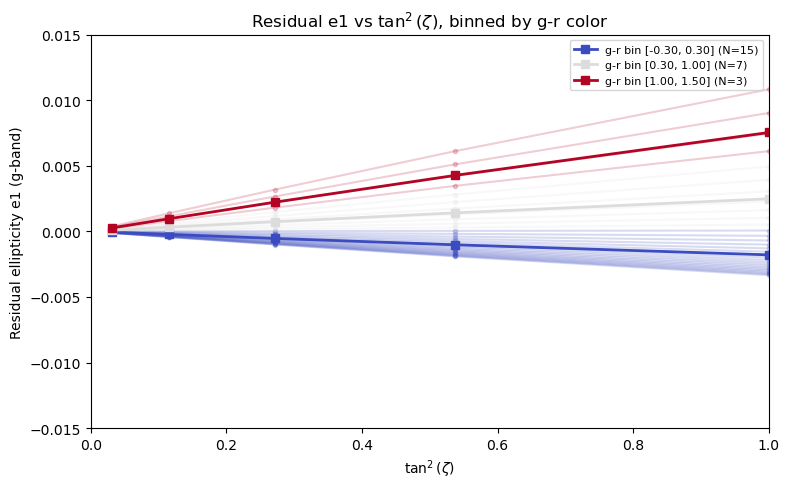

In [6]:
source_temperatures = np.linspace(2500, 9000, 30)
source_temperatures = np.flip(source_temperatures)  # hot (blue) → cool (red)
zeniths = np.linspace(10, 45, 5)
tan2z = np.tan(np.deg2rad(zeniths))**2  # x-axis: DCR scales as tan²(ζ)

# Baseline: fiducial 5000 K source used as reference point for residuals
DCR1_base, DCR2_base, e1_base, e2_base = BB_dcr(5000, 4500, zeniths, shape_xx, shape_yy, shape_xy)

gr_colors = []
resid_e1_list = []
resid_e1s = {}

for source_temperature in source_temperatures:
    DCR1, DCR2, e1, e2, mags = BB_dcr(source_temperature, 4500, zeniths, shape_xx, shape_yy, shape_xy, return_mags=True)
    gr = mags['g'] - mags['r']  # g−r color as SED proxy
    resid = e1['g'] - e1_base['g']  # residual vs. 5000 K baseline
    resid_e1s[gr] = resid
    gr_colors.append(gr)
    resid_e1_list.append(resid)

gr_colors = np.array(gr_colors)
resid_e1_arr = np.array(resid_e1_list)  # shape: (n_temps, n_zeniths)

# Bin edges in g−r color (roughly: blue / solar / red)
bin_edges = np.array([-0.3, 0.3, 1.0, 1.5])
n_bins = len(bin_edges) - 1
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

cmap = plt.cm.coolwarm
fig, ax = plt.subplots(figsize=(8, 5))

# Individual SED tracks (faint)
for i, (gr, resid) in enumerate(zip(gr_colors, resid_e1_arr)):
    bin_idx = np.clip(np.digitize(gr, bin_edges) - 1, 0, n_bins - 1)
    color = cmap(bin_idx / (n_bins - 1))
    ax.plot(tan2z, resid, '-o', color=color, alpha=0.2, markersize=3)

# Binned averages (bold)
for b in range(n_bins):
    mask = (gr_colors >= bin_edges[b]) & (gr_colors < bin_edges[b + 1])
    if b == n_bins - 1:
        mask = (gr_colors >= bin_edges[b]) & (gr_colors <= bin_edges[b + 1])
    if mask.sum() == 0:
        continue
    avg_resid = resid_e1_arr[mask].mean(axis=0)
    color = cmap(b / (n_bins - 1))
    ax.plot(tan2z, avg_resid, '-s', color=color, alpha=1.0, linewidth=2, markersize=6,
            label=f'g-r bin [{bin_edges[b]:.2f}, {bin_edges[b+1]:.2f}] (N={mask.sum()})')

ax.set_xlabel(r'$\tan^2(\zeta)$')
ax.set_ylabel('Residual ellipticity e1 (g-band)')
ax.legend(fontsize=8)
ax.set_title(r'Residual e1 vs $\tan^2(\zeta)$, binned by g-r color')
ax.set_ylim(-0.015, 0.015)
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()


## 6. SED Counts per g−r Color Bin

A quick sanity check: how many of the 30 blackbody SEDs fall into each g−r bin? The linear temperature grid produces uneven g−r coverage (colors compress toward the red end), so this verifies the bin occupancies before interpreting the averaged residuals above.

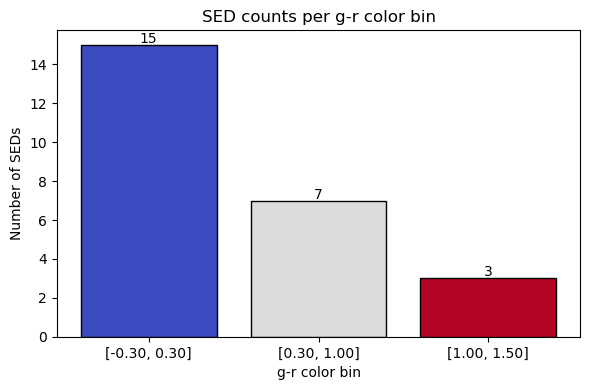

In [7]:
# Histogram of counts per g-r color bin
counts = []
labels = []
bar_colors = []
cmap = plt.cm.coolwarm

for b in range(n_bins):
    if b == n_bins - 1:
        mask = (gr_colors >= bin_edges[b]) & (gr_colors <= bin_edges[b + 1])
    else:
        mask = (gr_colors >= bin_edges[b]) & (gr_colors < bin_edges[b + 1])
    counts.append(mask.sum())
    labels.append(f'[{bin_edges[b]:.2f}, {bin_edges[b+1]:.2f}]')
    bar_colors.append(cmap(b / (n_bins - 1)))

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(range(n_bins), counts, color=bar_colors, edgecolor='k')
ax.set_xticks(range(n_bins))
ax.set_xticklabels(labels)
ax.set_xlabel('g-r color bin')
ax.set_ylabel('Number of SEDs')
ax.set_title('SED counts per g-r color bin')
for i, c in enumerate(counts):
    ax.text(i, c + 0.1, str(c), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

---

## 7. Extended Sources: DCR Residual for Galaxies with Intrinsic Shapes

For an extended source like a galaxy, the observed second moments are the galaxy's intrinsic moments *plus* the PSF moments. DCR adds to the PSF moments along the **altitude axis**, but the orientation of altitude in the RA/Dec frame rotates from visit to visit with the **parallactic angle** $q$.

### Coordinate frames

| Frame | Axes | What lives here |
|---|---|---|
| **RA/Dec** (sky) | $x$ = east, $y$ = north | Galaxy intrinsic shape — fixed across visits |
| **Alt/Az** | $x$ = azimuth, $y$ = altitude | DCR adds only to $I_{yy}$ (altitude direction) |

The **parallactic angle** $q$ is the angle from north toward east to the zenith direction, as seen on the sky. The altitude unit vector in RA/Dec coordinates is therefore:

$$\hat{u}_\text{alt} = (\sin q,\; \cos q) \qquad (x=\text{east},\; y=\text{north})$$

### DCR contribution in RA/Dec

A broadening DCR2 along $\hat{u}_\text{alt}$ adds to the RA/Dec second moments as the outer product $\Delta I_{ab} = \text{DCR2} \cdot \hat{u}_a \hat{u}_b$:

$$\Delta I_{xx} = \text{DCR2}\cdot\sin^2 q, \qquad \Delta I_{yy} = \text{DCR2}\cdot\cos^2 q, \qquad \Delta I_{xy} = \text{DCR2}\cdot\sin q\cos q$$

The total observed moments in visit $i$ (with parallactic angle $q_i$, zenith angle $\zeta_i$) are:

$$I_{xx}^\text{obs} = I_{xx}^0 + \text{DCR2}_i\,\sin^2 q_i, \qquad I_{yy}^\text{obs} = I_{yy}^0 + \text{DCR2}_i\,\cos^2 q_i, \qquad I_{xy}^\text{obs} = I_{xy}^0 + \text{DCR2}_i\,\sin q_i\cos q_i$$

where $I^0 = I_\text{galaxy} + I_\text{PSF}$ is the total pre-DCR moment (galaxy + achromatic PSF). The **DCR ellipticity residual** is $\Delta e_i = e(I^\text{obs}_i) - e(I^0)$.

### Rotation matrix formulation (equivalent)

The same result can be derived by explicitly rotating frames. The rotation matrix from RA/Dec to Alt/Az is:

$$R(q) = \begin{pmatrix} \cos q & -\sin q \\ \sin q & \cos q \end{pmatrix}$$

Then: $I_\text{AltAz} = R(q)\,I_\text{sky}\,R(q)^\top$, add DCR2 to $I_\text{AltAz}[1,1]$, rotate back $I_\text{sky}^\text{obs} = R(q)^\top I_\text{AltAz}^\text{obs} R(q)$.

### Expected pattern

For a nearly circular source with total moment $I_0 = I_{xx}^0 \approx I_{yy}^0$ and $I_{xy}^0 \approx 0$, a first-order expansion gives:

$$\Delta e_1 \approx -\frac{\text{DCR2}}{2 I_0}\cos(2q), \qquad \Delta e_2 \approx +\frac{\text{DCR2}}{2 I_0}\sin(2q)$$

The DCR residual traces a **circle** in the $(e_1, e_2)$ plane as $q$ varies from $0$ to $2\pi$, with amplitude $\text{DCR2} / (2 I_0)$ that scales as $\tan^2(\zeta)$.

In [8]:
def ellipticity(Ixx, Iyy, Ixy):
    """Distortion-convention ellipticity (e1, e2) from second moments."""
    det = np.maximum(Ixx * Iyy - Ixy**2, 0)
    denom = Ixx + Iyy + 2 * np.sqrt(det)
    return (Ixx - Iyy) / denom, 2 * Ixy / denom

def dcr_sky_moments(DCR2, q_rad):
    """
    DCR2 contribution to RA/Dec second moments given parallactic angle q.
    The altitude direction in (east, north) sky coords is û_alt = (sin q, cos q),
    so a broadening DCR2 along altitude adds ΔI_ab = DCR2 * û_a * û_b.
    """
    s, c = np.sin(q_rad), np.cos(q_rad)
    return DCR2 * s**2, DCR2 * c**2, DCR2 * s * c

def rotate_moments(Ixx, Iyy, Ixy, theta):
    """Rotate second moments by angle theta (radians), counterclockwise."""
    c, s = np.cos(theta), np.sin(theta)
    Ixx_r = Ixx * c**2 + 2 * Ixy * c * s + Iyy * s**2
    Iyy_r = Ixx * s**2 - 2 * Ixy * c * s + Iyy * c**2
    Ixy_r = (Iyy - Ixx) * c * s + Ixy * (c**2 - s**2)
    return Ixx_r, Iyy_r, Ixy_r

# Galaxy intrinsic shape moments in RA/Dec (x=east, y=north), in arcsec²
# These are fixed properties of the source — independent of observation geometry
Ixx_gal = 0.05  # elongated slightly along east-west
Iyy_gal = 0.03
Ixy_gal = 0.01  # small tilt

# The circular achromatic PSF (from earlier) adds equally to both axes
# shape_xx = shape_yy = 6*(0.2²), shape_xy = 0
Ixx0 = Ixx_gal + shape_xx  # total pre-DCR Ixx: galaxy + PSF
Iyy0 = Iyy_gal + shape_yy  # total pre-DCR Iyy
Ixy0 = Ixy_gal              # circular PSF contributes no cross-term

e1_nodcr, e2_nodcr = ellipticity(Ixx0, Iyy0, Ixy0)
print(f"Galaxy moments (RA/Dec):  Ixx_gal={Ixx_gal:.4f}, Iyy_gal={Iyy_gal:.4f}, Ixy_gal={Ixy_gal:.4f} arcsec²")
print(f"Total pre-DCR moments:    Ixx0={Ixx0:.4f},     Iyy0={Iyy0:.4f},     Ixy0={Ixy0:.4f} arcsec²")
print(f"Pre-DCR ellipticity:      e1={e1_nodcr:.4f},  e2={e2_nodcr:.4f}")


Galaxy moments (RA/Dec):  Ixx_gal=0.0500, Iyy_gal=0.0300, Ixy_gal=0.0100 arcsec²
Total pre-DCR moments:    Ixx0=0.2900,     Iyy0=0.2700,     Ixy0=0.0100 arcsec²
Pre-DCR ellipticity:      e1=0.0179,  e2=0.0179


### DCR residual vs. parallactic angle

We now sweep the parallactic angle from 0° to 360° at a fixed zenith angle and compute the DCR residual $\Delta e_1 = e_1^\text{obs} - e_1^0$ and $\Delta e_2 = e_2^\text{obs} - e_2^0$. Because the DCR contribution rotates with $q$, both components oscillate as $\cos(2q)$ and $\sin(2q)$. Plotting the residual in the $(e_1, e_2)$ plane should reveal an approximately elliptical locus — a perfect circle for a round pre-DCR source, deformed by the intrinsic shape asymmetry.

<>:24: SyntaxWarning: invalid escape sequence '\D'
<>:30: SyntaxWarning: invalid escape sequence '\D'
<>:36: SyntaxWarning: invalid escape sequence '\D'
<>:37: SyntaxWarning: invalid escape sequence '\D'
<>:24: SyntaxWarning: invalid escape sequence '\D'
<>:30: SyntaxWarning: invalid escape sequence '\D'
<>:36: SyntaxWarning: invalid escape sequence '\D'
<>:37: SyntaxWarning: invalid escape sequence '\D'
/var/folders/ns/g2qjv9ld66v981bvx8j2b4zh0000gn/T/ipykernel_11051/4039591436.py:24: SyntaxWarning: invalid escape sequence '\D'
  axes[0].set_ylabel('$\Delta e_1$')
/var/folders/ns/g2qjv9ld66v981bvx8j2b4zh0000gn/T/ipykernel_11051/4039591436.py:30: SyntaxWarning: invalid escape sequence '\D'
  axes[1].set_ylabel('$\Delta e_2$')
/var/folders/ns/g2qjv9ld66v981bvx8j2b4zh0000gn/T/ipykernel_11051/4039591436.py:36: SyntaxWarning: invalid escape sequence '\D'
  axes[2].set_xlabel('$\Delta e_1$')
/var/folders/ns/g2qjv9ld66v981bvx8j2b4zh0000gn/T/ipykernel_11051/4039591436.py:37: SyntaxWarning: in

DCR2 (g-band, ζ=30.0°, 5000 K source): 0.011276 arcsec²


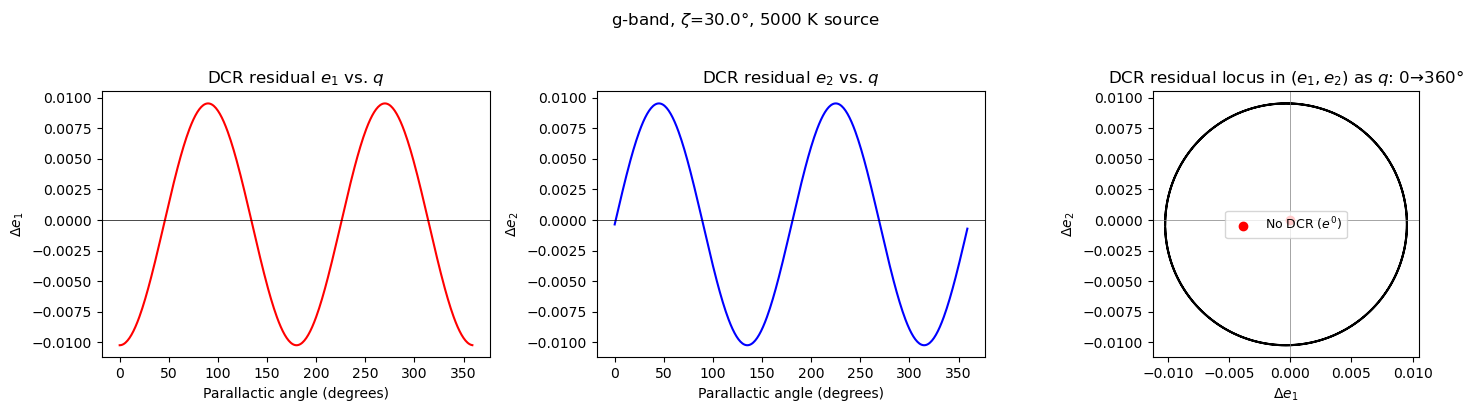

In [9]:
parallactic_angles_deg = np.linspace(0, 360, 360, endpoint=False)
q_rad_sweep = np.deg2rad(parallactic_angles_deg)

zenith_fixed = 30.0  # degrees
# Compute DCR2 for our fiducial 5000 K source in g-band at this zenith
DCR1_f, DCR2_f, _, _ = BB_dcr(5000, 4500, [zenith_fixed], shape_xx, shape_yy, shape_xy)
dcr2_g = DCR2_f['g'][0]
print(f"DCR2 (g-band, ζ={zenith_fixed}°, 5000 K source): {dcr2_g:.6f} arcsec²")

de1 = np.zeros(len(q_rad_sweep))
de2 = np.zeros(len(q_rad_sweep))

for i, q in enumerate(q_rad_sweep):
    dIxx, dIyy, dIxy = dcr_sky_moments(dcr2_g, q)
    e1_obs, e2_obs = ellipticity(Ixx0 + dIxx, Iyy0 + dIyy, Ixy0 + dIxy)
    de1[i] = e1_obs - e1_nodcr
    de2[i] = e2_obs - e2_nodcr

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(parallactic_angles_deg, de1, 'r-')
axes[0].axhline(0, color='k', lw=0.5)
axes[0].set_xlabel('Parallactic angle (degrees)')
axes[0].set_ylabel('$\Delta e_1$')
axes[0].set_title('DCR residual $e_1$ vs. $q$')

axes[1].plot(parallactic_angles_deg, de2, 'b-')
axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_xlabel('Parallactic angle (degrees)')
axes[1].set_ylabel('$\Delta e_2$')
axes[1].set_title('DCR residual $e_2$ vs. $q$')

# Locus in (e1, e2) space — should approximate a circle for a round source
axes[2].plot(de1, de2, 'k-', lw=1.5)
axes[2].scatter([0], [0], color='red', zorder=5, label='No DCR ($e^0$)')
axes[2].set_xlabel('$\Delta e_1$')
axes[2].set_ylabel('$\Delta e_2$')
axes[2].set_title('DCR residual locus in $(e_1, e_2)$ as $q$: 0→360°')
axes[2].set_aspect('equal')
axes[2].axhline(0, color='gray', lw=0.5)
axes[2].axvline(0, color='gray', lw=0.5)
axes[2].legend(fontsize=9)

plt.suptitle(f'g-band, $\\zeta$={zenith_fixed}°, 5000 K source', y=1.02)
plt.tight_layout()
plt.show()


### Zenith angle scaling and the analytic approximation

The amplitude of the locus scales as DCR2 $\propto \tan^2(\zeta)$. Overlaying the analytic approximation for a circular source confirms the $\cos(2q)$/$\sin(2q)$ structure:

$$\Delta e_1^\text{analytic} = -\frac{\text{DCR2}}{2 I_0}\cos(2q), \qquad \Delta e_2^\text{analytic} = +\frac{\text{DCR2}}{2 I_0}\sin(2q)$$

where $I_0 = (I_{xx}^0 + I_{yy}^0)/2$ is the mean pre-DCR moment. Deviations from this form signal the coupling between DCR and the intrinsic galaxy shape asymmetry.

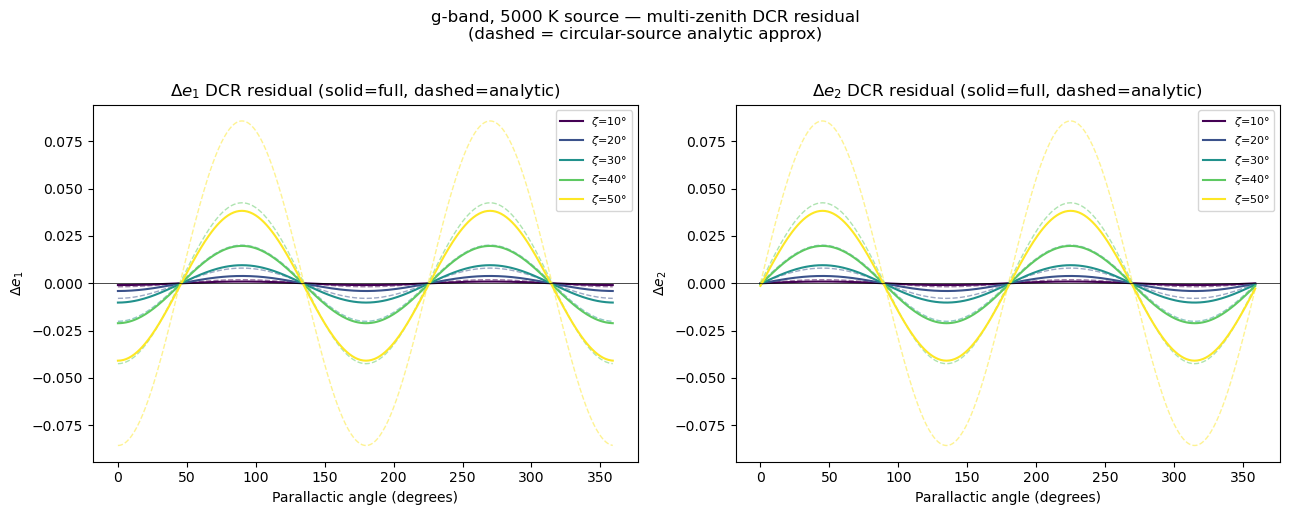

In [10]:
zenith_angles_ext = np.linspace(10, 50, 5)
I0 = 0.5 * (Ixx0 + Iyy0)  # mean pre-DCR moment for analytic approximation

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors_z = plt.cm.viridis(np.linspace(0, 1, len(zenith_angles_ext)))

for z, col in zip(zenith_angles_ext, colors_z):
    DCR1_z, DCR2_z, _, _ = BB_dcr(5000, 4500, [z], shape_xx, shape_yy, shape_xy)
    dcr2 = DCR2_z['g'][0]

    de1_z = np.zeros(len(q_rad_sweep))
    de2_z = np.zeros(len(q_rad_sweep))
    for i, q in enumerate(q_rad_sweep):
        dIxx, dIyy, dIxy = dcr_sky_moments(dcr2, q)
        e1_obs, e2_obs = ellipticity(Ixx0 + dIxx, Iyy0 + dIyy, Ixy0 + dIxy)
        de1_z[i] = e1_obs - e1_nodcr
        de2_z[i] = e2_obs - e2_nodcr

    # Analytic approximation for a circular source
    de1_analytic = -(dcr2 / (2 * I0)) * np.cos(2 * q_rad_sweep)
    de2_analytic =  (dcr2 / (2 * I0)) * np.sin(2 * q_rad_sweep)

    axes[0].plot(parallactic_angles_deg, de1_z, color=col, label=f'$\\zeta$={z:.0f}°')
    axes[0].plot(parallactic_angles_deg, de1_analytic, color=col, lw=1, ls='--', alpha=0.5)

    axes[1].plot(parallactic_angles_deg, de2_z, color=col, label=f'$\\zeta$={z:.0f}°')
    axes[1].plot(parallactic_angles_deg, de2_analytic, color=col, lw=1, ls='--', alpha=0.5)

for ax, lbl in zip(axes, ['$\\Delta e_1$', '$\\Delta e_2$']):
    ax.axhline(0, color='k', lw=0.5)
    ax.set_xlabel('Parallactic angle (degrees)')
    ax.set_ylabel(lbl)
    ax.set_title(f'{lbl} DCR residual (solid=full, dashed=analytic)')
    ax.legend(fontsize=8)

plt.suptitle('g-band, 5000 K source — multi-zenith DCR residual\n(dashed = circular-source analytic approx)', y=1.02)
plt.tight_layout()
plt.show()


### DCR residual in Alt/Az: the natural frame for real data

The plots above express the residual in RA/Dec, where the DCR contribution oscillates with $q$. A more natural approach for real data is to **rotate all moments into Alt/Az first** — the frame where DCR acts — and then examine the residual as a function of zenith angle:

1. Rotate observed RA/Dec moments to Alt/Az: $I_\text{AltAz} = R(q)\,I_\text{sky}\,R(q)^\top$
2. In Alt/Az the DCR residual is purely in the altitude component: $I_{yy,\text{AltAz}}^\text{obs} = I_{yy,\text{AltAz}}^0 + \text{DCR2}$
3. The residual $\Delta e_\text{AltAz}$ vs. $\tan^2(\zeta)$ should be a clean (approximately linear) curve

The parallactic angle still enters because the projected altitude-axis moment $I_{yy,\text{AltAz}}^0 = [R(q)\,I^0\,R(q)^\top]_{yy}$ depends on $q$. When the galaxy's intrinsic long axis is aligned with altitude ($I_{yy,\text{AltAz}}$ large), the denominator of the ellipticity formula is larger and the DCR signal is diluted; when the long axis is perpendicular to altitude ($I_{xx,\text{AltAz}}$ large), the effect is stronger. A round galaxy is rotation-invariant so its residual curve is the same for all $q$.

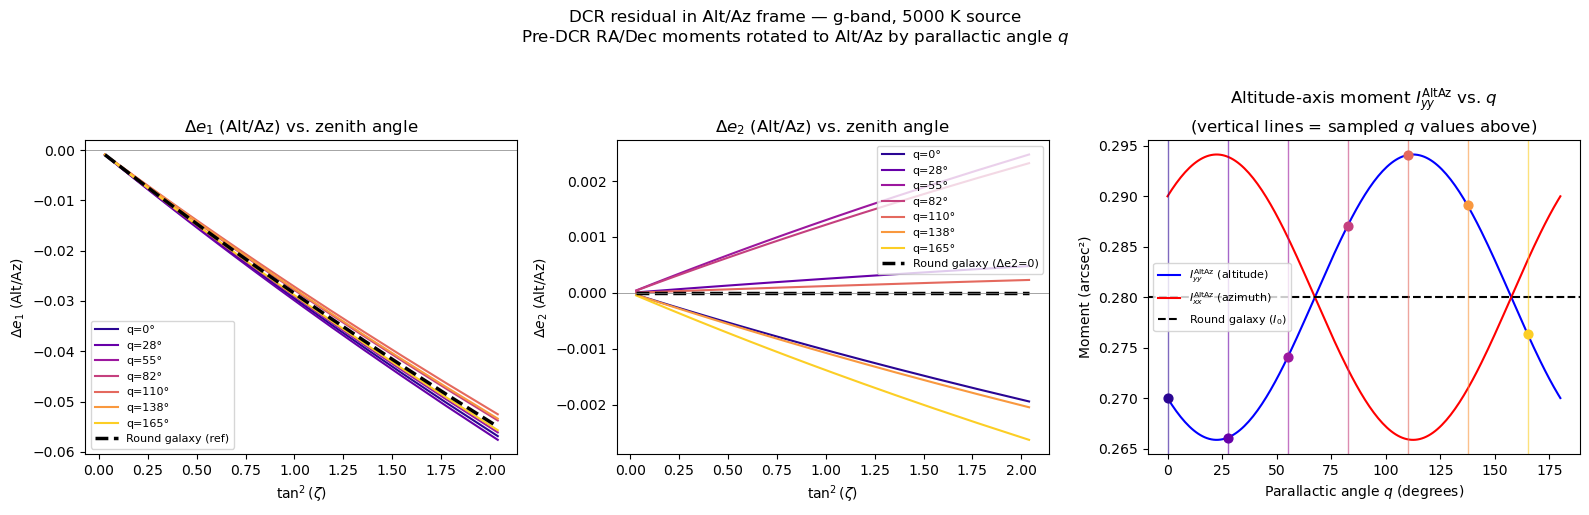

In [ ]:
# Precompute DCR2(ζ) for all zenith angles in one call (more efficient than one call per ζ)
zenith_plot = np.linspace(10, 55, 25)
tan2z_plot = np.tan(np.deg2rad(zenith_plot))**2
_, DCR2_all, _, _ = BB_dcr(5000, 4500, zenith_plot, shape_xx, shape_yy, shape_xy)
dcr2_vs_z = DCR2_all['g']  # g-band DCR2 as a function of ζ

q_values_deg = np.linspace(0, 165, 7)  # sample parallactic angles (0°–165° spans the full range of q mod 180°)
colors_q = plt.cm.plasma(np.linspace(0.05, 0.9, len(q_values_deg)))

# Round galaxy reference: same total moment as our galaxy, but circular (Ixx=Iyy, Ixy=0)
# A circle is rotation-invariant, so its Alt/Az residual is the same for all q
I_round = 0.5 * (Ixx0 + Iyy0)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

Iyy_altaz_vs_q = []  # track the altitude-axis moment vs q (explains spread in residuals)

for q_deg, col in zip(q_values_deg, colors_q):
    q = np.deg2rad(q_deg)

    # Rotate pre-DCR moments from RA/Dec to Alt/Az
    Ixx_az, Iyy_az, Ixy_az = rotate_moments(Ixx0, Iyy0, Ixy0, q)
    e1_pre, e2_pre = ellipticity(Ixx_az, Iyy_az, Ixy_az)
    Iyy_altaz_vs_q.append(Iyy_az)

    # DCR adds only to the altitude component (Iyy_az); compute residual vs. ζ
    de1_az = np.array([ellipticity(Ixx_az, Iyy_az + d, Ixy_az)[0] - e1_pre for d in dcr2_vs_z])
    de2_az = np.array([ellipticity(Ixx_az, Iyy_az + d, Ixy_az)[1] - e2_pre for d in dcr2_vs_z])

    axes[0].plot(tan2z_plot, de1_az, color=col, label=f'q={q_deg:.0f}°')
    axes[1].plot(tan2z_plot, de2_az, color=col, label=f'q={q_deg:.0f}°')

# Round-galaxy reference (same curve for all q — rotation invariant)
de1_round = np.array([ellipticity(I_round, I_round + d, 0.0)[0] for d in dcr2_vs_z])
axes[0].plot(tan2z_plot, de1_round, 'k--', lw=2.5, label='Round galaxy (ref)')
axes[1].plot(tan2z_plot, np.zeros_like(tan2z_plot), 'k--', lw=2.5, label='Round galaxy (Δe2=0)')

for ax, lbl in zip(axes[:2], ['$\\Delta e_1$ (Alt/Az)', '$\\Delta e_2$ (Alt/Az)']):
    ax.axhline(0, color='gray', lw=0.5)
    ax.set_xlabel('$\\tan^2(\\zeta)$')
    ax.set_ylabel(lbl)
    ax.set_title(f'{lbl} vs. zenith angle')
    ax.legend(fontsize=8)

# Third panel: Iyy_altaz vs q — shows why the spread in residuals exists.
# DCR adds to Iyy_altaz; when Iyy_altaz is large (galaxy elongated along altitude),
# the DCR signal is diluted by the larger denominator of the ellipticity formula.
q_fine = np.linspace(0, 180, 180)
Iyy_az_fine = np.array([rotate_moments(Ixx0, Iyy0, Ixy0, np.deg2rad(q))[1] for q in q_fine])
Ixx_az_fine = np.array([rotate_moments(Ixx0, Iyy0, Ixy0, np.deg2rad(q))[0] for q in q_fine])
axes[2].plot(q_fine, Iyy_az_fine, 'b-', label='$I_{yy}^\\text{AltAz}$ (altitude)')
axes[2].plot(q_fine, Ixx_az_fine, 'r-', label='$I_{xx}^\\text{AltAz}$ (azimuth)')
axes[2].axhline(I_round, color='k', ls='--', lw=1.5, label='Round galaxy ($I_0$)')
for q_deg, col in zip(q_values_deg, colors_q):
    Iyy_q = rotate_moments(Ixx0, Iyy0, Ixy0, np.deg2rad(q_deg))[1]
    axes[2].axvline(q_deg, color=col, lw=1, alpha=0.6)
    axes[2].scatter([q_deg], [Iyy_q], color=col, zorder=5, s=40)
axes[2].set_xlabel('Parallactic angle $q$ (degrees)')
axes[2].set_ylabel('Moment (arcsec²)')
axes[2].set_title('Altitude-axis moment $I_{yy}^\\text{AltAz}$ vs. $q$\n(vertical lines = sampled $q$ values above)')
axes[2].legend(fontsize=8)

plt.suptitle('DCR residual in Alt/Az frame — g-band, 5000 K source\n'
             'Pre-DCR RA/Dec moments rotated to Alt/Az by parallactic angle $q$', y=1.02)
plt.tight_layout()
plt.show()
